# Data Collection and Preparation - Health Emergencies Preparedness and Response Program (HEPR)

This notebook is a template workflow to collect data and prepare the main data to perform a baseline physical accessibility analysis to health facilities. It uses various tools developed by the World Bank's Geospatial Operations Support Team (GOST).

This notebook focuses on a raster-based implementation of market access, using the motorized Global Friction Surface from the [Malaria Atlas Project](https://malariaatlas.org/project-resources/accessibility-to-healthcare/).
Additionaly, it uses population data from [World Pop](https://hub.worldpop.org/project/categories?id=3) (Unconstrained UN-Adjusted 2020, 1km resolution).

## Data Download Links
- [World Pop Raster](https://data.worldpop.org/GIS/Population/Global_2000_2020_1km/2020/)
- [Friction Surface](https://malariaatlas.org/geoserver/ows?service=CSW&version=2.0.1&request=DirectDownload&ResourceId=Explorer:2020_motorized_travel_time_to_healthcare)
- [Healthcare Facilities](https://opendata.com.pk/dataset/pakistan-health-sites)

## Setup

Import packages required for the analysis

In [1]:
# System
import sys
import os
from os.path import join, expanduser
from pathlib import Path
# Avoid warnings to pop up
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Visualization tools
# import folium as flm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from rasterio.plot import plotting_extent
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

os.environ['CARTOPY_USER_BACKGROUNDS'] = '/home/jupyter-wb618081/Python/Backgrounds/'

In [3]:
# Processing 
import numpy as np
import geopandas as gpd
import pandas as pd
from gadm import GADMDownloader

# Raster
import rasterio as rio
from rasterio.features import shapes
from shapely.geometry import box
from rasterio.features import geometry_mask
from rasterstats import zonal_stats
from shapely.geometry import Polygon, box, Point
from shapely.geometry import mapping
import skimage.graph as graph
from scipy.signal import convolve2d

# Graph
import pickle
import networkx as nx
import osmnx as ox

# for facebook data
# from pyquadkey2 import quadkey

In [4]:
# Parallelization
import multiprocessing
import dask
import dask_geopandas as dask_gpd
import rioxarray as rioxr

In [5]:
# Define your path to the Repositories

sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'gostrocks', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTNets_Raster', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTnets'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOST_Urban', 'src', 'GOST_Urban'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'health-equity-diagnostics', 'src', 'modules'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'INFRA_SAP'))

import GOSTnets as gn
from GOSTnets.load_osm import *
import GOSTRocks.rasterMisc as rMisc
from GOSTRocks.misc import get_utm
import GOSTNetsRaster.market_access as ma
import UrbanRaster as urban

from infrasap import aggregator
from infrasap import osm_extractor as osm   

from utils import download_osm_shapefiles

In [6]:
# auto reload
%load_ext autoreload
%autoreload 2

Define below the local folder where you are located

In [7]:
data_dir = join(expanduser("/home/jupyter-wb618081"), 'data')
scratch_dir = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics')
out_path = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics', 'Output')

## Data Preparation

### Administrative boundaries

In [8]:
epsg = "EPSG:4326"
epsg_utm = "EPSG:32736"

In [9]:
country = 'Pakistan'
iso = 'PAK'
downloader = GADMDownloader(version="4.0")
adm0 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=0)
adm1 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=1)
adm2 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=2)

adm1.rename(columns={"NAME_1":"ADM1"}, inplace=True) 
adm2.rename(columns={"NAME_1":"ADM1","NAME_2":"ADM2"}, inplace=True) 

In [10]:
# iso = 'MWI'
# adm0_path = join(expanduser("R:/"), 'Data', 'GLOBAL/ADMIN', f'Admin0_Polys.shp')
# adm0 = gpd.read_file(adm0_path)
# adm0 = adm0[adm0["ISO3"] == "MWI"].to_crs(4326)

# iso = 'MWI'
# adm2_path = join(expanduser("R:/"), 'Data', 'GLOBAL/ADMIN', f'Admin2_Polys.shp')
# adm2 = gpd.read_file(adm2_path)
# adm2 = adm2[adm2["ISO3"] == "MWI"].to_crs(4326)

### Population (origin)

In [11]:
# wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020/MOSAIC_ppp_prj_2020', f'ppp_prj_2020_{iso}.tif') # Download from link above
wp_path = join(data_dir, f'ppp_2020_1km_Aggregated.tif') # Download from link above

pop_surf = rio.open(wp_path)

### Health Facilities (destinations)

In [12]:
# BHU (Basic Health Unit)
# CD/GD (Civil Dispensary)  
# RHC (Rural Health Center)
# SHC (Secondary Health Care)

hf_path = join(data_dir, iso, "health_facilities/", 'pakistan.csv')
df_hf = pd.read_csv(hf_path, header = 0)
df_hf = df_hf[["X", "Y", "osm_id", "amenity"]]; df_hf.rename(columns = {"osm_id": "ID", "amenity": "Facility Type"}, inplace = True)

display('The following categories and numbers of Health Facilities are considered to perform the analysis: ')
display(df_hf["Facility Type"].value_counts())

# Consider all health facilities and hospitals

df_hf_hosp = df_hf.loc[df_hf['Facility Type'] == "hospital"]

'The following categories and numbers of Health Facilities are considered to perform the analysis: '

hospital    1673
clinic       633
pharmacy     528
doctors      187
dentist       41
Name: Facility Type, dtype: int64

In [13]:
# Convert from pandas.Dataframe to Geopandas.dataframe

geodf_hf = gpd.GeoDataFrame(
    df_hf, geometry=gpd.points_from_xy(df_hf.X, df_hf.Y), crs=epsg
)

geodf_hf_hosp = gpd.GeoDataFrame(
    df_hf_hosp, geometry=gpd.points_from_xy(df_hf_hosp.X, df_hf_hosp.Y), crs=epsg
)

# Clean the geodf
geodf_hf = geodf_hf[['ID', 'Facility Type', 'geometry']]; #geodf_hf.loc[:, 'ID'] = df_hf.index
geodf_hf_hosp = geodf_hf_hosp[['ID', 'Facility Type', 'geometry']]; # geodf_hf_hosp.loc[:, 'ID'] = df_hf_hosp.index

geodf_hf = geodf_hf[~geodf_hf.geometry.is_empty]
geodf_hf_hosp = geodf_hf_hosp[~geodf_hf_hosp.geometry.is_empty]

Assure correspondence of ADM1 names in Health facilities and official Administrative Units

In [14]:
geodf_hf = gpd.sjoin(geodf_hf, adm1[["ADM1", "geometry"]], op='within', how='left')
geodf_hf.drop(columns = ["index_right"], inplace = True)

geodf_hf_hosp = gpd.sjoin(geodf_hf_hosp, adm1[["ADM1", "geometry"]], op='within', how='left')
geodf_hf_hosp.drop(columns = ["index_right"], inplace = True)

### Flood

Here, we import Fathom flood data (.tif) of fluvial floods with different return periods. \
This data represent and mimic the climate impact on infrastructure and the disruption of the accessibility to health facilities.  

In [15]:
# Import multiple rasterio .tif file as a dictionary
# Keys are return periods
# Values are rasterio arrays

# inland waters and oceans: 999
# not-flooded areas: -999 (Fluvial)
# not-flooded areas: 0 (Pluvial)
# Other values represent the flood depth (in m)

flood_fluvial_path = join(data_dir, iso,'FLOOD_SSBN','fluvial_undefended')
flood_pluvial_path = join(data_dir, iso,'FLOOD_SSBN','pluvial')

files=os.listdir(flood_fluvial_path)
flood_dict_fluvial = {}
for file in files:
    key = file.split('_')[1].split('.')[0]
    value = rio.open(join(flood_fluvial_path,file)) #.read(1)
    flood_dict_fluvial[key] = value

files=os.listdir(flood_pluvial_path)
flood_dict_pluvial = {}
for file in files:
    key = file.split('_')[1].split('.')[0]
    value = rio.open(join(flood_pluvial_path,file)) #.read(1)
    flood_dict_pluvial[key] = value

# Preserve the maximum flood depth
flood_dict = {}
flood_dict_rio = {}
for f,key in enumerate(flood_dict_pluvial.keys()):
    out_flood_path = join(data_dir, iso,'FLOOD_SSBN', 'Fmax_' + key +'.tif')
    if os.path.isfile(out_flood_path):
        value = rioxr.open_rasterio(out_flood_path, chunks = 1000)
        value_rio = rio.open(out_flood_path) 
        flood_dict[key] = value
        flood_dict_rio[key] = value_rio
    else:
        out_meta = flood_dict_pluvial[key].meta
        flood_max = np.fmax(flood_dict_fluvial[key].read(1),flood_dict_pluvial[key].read(1))
        flood_dict[key] = flood_max
        # flood_dict[key][flood_dict[key] == 0] = -999
        # Write the output raster
        out_flood_path = join(data_dir, iso,'FLOOD_SSBN', 'Fmax_' + key +'.tif')
        with rio.open(out_flood_path, 'w', **out_meta) as dst:
            dst.write(flood_max, 1)
        # Read the output raster
        value = rioxr.open_rasterio(out_flood_path) 
        flood_dict[key] = value

# Free up memory
for f,key in enumerate(flood_dict.keys()):
        del flood_dict_fluvial[key]
        del flood_dict_pluvial[key]


### Friction Surface

Process the travel cost surface from the Malaria Atlas Project, clip the raster to our region of interest.

In [16]:
# Only the first time, clip the travel friction surface to the country of interest
out_travel_surface = join(data_dir, iso, f"travel_surface_motorized_{iso}.tif")

if not os.path.isfile(out_travel_surface):
    gfs_path = join(data_dir, '2020_motorized_friction_surface.geotiff')
    gfs_rio = rio.open(gfs_path)
    rMisc.clipRaster(gfs_rio, adm0, out_travel_surface, crop=False)

# Import the clipped friction surface
travel_surf = rio.open(out_travel_surface) #.read(1)

In [17]:
print(travel_surf.res)
print(pop_surf.res)

(0.008333333333333333, 0.008333333333333333)
(0.0083333333, 0.0083333333)


### Preprocessing



Align the POPULATION & FLOOD raster to the friction surface, ensuring that they have the same extent and resolution.

In [18]:
# If the Standardized data are already present, skip, else generate them

def checkDir(out_path):
    if not os.path.exists(out_path):
        os.makedirs(out_path)

checkDir(join(out_path, iso))

out_pop_surface_std = join(out_path, iso, "WP_2020_1km_STD.tif")
if not os.path.isfile(out_pop_surface_std):
    rMisc.standardizeInputRasters(pop_surf, travel_surf, out_pop_surface_std, resampling_type="nearest")

checkDir(join(out_path, iso, "flood"))

for f,key in enumerate(flood_dict.keys()):
    # out_flood_path = join(data_dir, iso,'FLOOD_SSBN', 'Fmax_' + key)
    out_flood_std = join(out_path, iso, 'flood', "STD_" + 'Fmax_'+ key +'.tif')
    if os.path.isfile(out_flood_std):
        None
    else:
        rMisc.standardizeInputRasters(flood_dict[key], travel_surf, out_flood_std, resampling_type="nearest")

Correct the reprojected FLOOD raster extension, ensuring that lands are not covered by inland and open waters

In [19]:
# Import multiple rasterio .tif file as a dictionary
# Keys are return periods
# Values are rasterio arrays

flood_path = join(out_path, iso, 'flood')
files=os.listdir(flood_path)

flood_dict_std = {}
for file in files:
    if file.startswith('STD') == True:
        key = file.split('_')[2].split('.')[0]
        value = rio.open(join(flood_path,file)) #.read(1)
        flood_dict_std[key] = value

display(flood_dict_std["1in10"].read_crs())

CRS.from_epsg(4326)

### Origins

Prepare a standard grid (pandas.Dataframe) using each cell from the 1km World Pop raster.

In [20]:
pop_surf = rio.open(out_pop_surface_std)
pop = pop_surf.read(1, masked=False)

In [21]:
# Create a population df from population surface 
indices = list(np.ndindex(pop.shape))
xys = [Point(pop_surf.xy(ind[0], ind[1])) for ind in indices]
res_df = pd.DataFrame({
    'spatial_index': indices,
    'xy': xys,
    'pop': pop.flatten()
})
res_df['pointid'] = res_df.index
res_df

,spatial_index,xy,pop,pointid
0,"(0, 0)",POINT (60.89583333333332 37.09583333333333),8.048295,0
1,"(0, 1)",POINT (60.904166666666654 37.09583333333333),7.362457,1
2,"(0, 2)",POINT (60.91249999999999 37.09583333333333),9.171885,2
3,"(0, 3)",POINT (60.92083333333332 37.09583333333333),9.375657,3
4,"(0, 4)",POINT (60.92916666666665 37.09583333333333),8.939575,4
...,...,...,...,...
3272275,"(1607, 2030)",POINT (77.81249999999999 23.704166666666666),212.114243,3272275
3272276,"(1607, 2031)",POINT (77.82083333333333 23.704166666666666),141.163818,3272276
3272277,"(1607, 2032)",POINT (77.82916666666665 23.704166666666666),128.055283,3272277
3272278,"(1607, 2033)",POINT (77.83749999999998 23.704166666666666),100.614090,3272278


## Flood impact on Health facilities

Consider the raw Fmax flood rasters, thus exploiting the original FATHOM dataset resolution\
For every Standardized Flood layer (Return Period), extract Flood Depth on Health Facilities location

In [26]:
# Extract flood depth at every facility location

for key in flood_dict.keys():
    coords = [(x,y) for x, y in zip(geodf_hf_hosp.geometry.x, geodf_hf_hosp.geometry.y)]
    geodf_hf_hosp[key] = [x[0] for x in flood_dict_rio[key].sample(coords)]

    coords = [(x,y) for x, y in zip(geodf_hf.geometry.x, geodf_hf.geometry.y)]
    geodf_hf[key] = [x[0] for x in flood_dict_rio[key].sample(coords)]


In [27]:
# Identify Flooded and not Flooded Facilities 

flood_geodf_hf_hosp = {}
dry_geodf_hf_hosp = {}
flood_geodf_hf = {}
dry_geodf_hf = {}
for key in flood_dict.keys():
    flood_geodf_hf_hosp[key] = geodf_hf_hosp[geodf_hf_hosp[key] > 0.2]
    dry_geodf_hf_hosp[key] = geodf_hf_hosp[geodf_hf_hosp[key] == 0]
    
    flood_geodf_hf[key] = geodf_hf[geodf_hf[key] > 0.2]
    dry_geodf_hf[key] = geodf_hf[geodf_hf[key] == 0]


### Summary statistics

For every Flood Scenario (RP):
- Number and % of Health facilities disrupted by Facility Type
- Number and % of Health facilities disrupted by ADM1 Districts

In [28]:
# Reorder Flood Return Periods in geodf columns

def sort_flood_col(gdf, str_start, str_sep):
    # Define str_start and str_sep as the strings that identify the start of column names and the separator with the numerical value
    fd_columns = [col for col in gdf.columns if col.startswith(str_start)]
    non_fd_columns = [col for col in gdf.columns if not col.startswith(str_start)]
    fd_num = [(int(col.split(str_sep)[1]), col) for col in fd_columns]
    fd_col_sort = [col for _, col in sorted(fd_num)]
    new_column_order = non_fd_columns + fd_col_sort
    # Reorder the DataFrame columns
    gdf = gdf[new_column_order]
    return(gdf)

geodf_hf = sort_flood_col(geodf_hf, "1in", "in")
geodf_hf_hosp = sort_flood_col(geodf_hf_hosp, "1in", "in")

In [29]:
# % of Facilities disrupted, by Facility Type

stats1 = geodf_hf[geodf_hf != 0].groupby("Facility Type").count().drop(columns = ["ADM1", "geometry"]).rename(columns={'ID': 'Total n°'})
fd_columns = [col for col in stats1.columns if col.startswith("1in")]
for col in fd_columns:
    stats1[col] = (stats1[col]/stats1["Total n°"])*100

stats1[fd_columns] = stats1[fd_columns].round(2)
display(stats1)

,Total n°,1in5,1in10,1in20,1in50,1in75,1in100,1in200,1in250,1in500,1in1000
Facility Type,,,,,,,,,,,
clinic,596,2.68,4.70,7.55,14.09,19.13,21.31,26.68,27.68,34.56,43.12
dentist,39,7.69,7.69,15.38,17.95,20.51,23.08,25.64,25.64,33.33,38.46
doctors,123,9.76,13.01,21.14,37.40,41.46,42.28,47.97,50.41,53.66,59.35
hospital,1352,3.25,5.18,8.88,16.27,20.04,23.74,32.17,33.80,43.42,49.63
pharmacy,506,2.57,4.15,6.32,13.83,18.97,23.52,29.25,30.04,39.13,44.07


In [30]:
stats1_long = pd.melt(stats1.reset_index().drop(columns = "Total n°"), id_vars="Facility Type", var_name="scen")
scen = stats1_long.scen.unique()

In [31]:
# % of Facilities disrupted, by ADM1 (Districts)

stats2 = geodf_hf[geodf_hf != 0].groupby("ADM1").count().drop(columns = ["Facility Type", "geometry"]).rename(columns={'ID': 'Total n°'})
fd_columns = [col for col in stats2.columns if col.startswith("1in")]
for col in fd_columns:
    stats2[col] = (stats2[col]/stats2["Total n°"])*100

stats2[fd_columns] = stats2[fd_columns].round(2)

# Merge with ADM1 geometries
stats2 = stats2.merge(adm1[["ADM1", "geometry"]], on='ADM1', how='left').set_index("ADM1")
stats2 =gpd.GeoDataFrame(stats2, geometry=stats2["geometry"], crs="EPSG:4326")
display(stats2)

,Total n°,1in5,1in10,1in20,1in50,1in75,1in100,1in200,1in250,1in500,1in1000,geometry
ADM1,,,,,,,,,,,,
Azad Kashmir,12,8.33,8.33,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00,"MULTIPOLYGON (((73.82016 33.01731, 73.78817 33..."
Balochistan,38,0.00,0.00,2.63,7.89,15.79,18.42,26.32,31.58,42.11,44.74,"MULTIPOLYGON (((63.85792 25.12653, 63.85792 25..."
Federally Administered Tribal Areas,7,0.00,0.00,0.00,0.00,0.00,14.29,14.29,14.29,14.29,28.57,"MULTIPOLYGON (((70.19426 31.09286, 70.18851 31..."
Gilgit-Baltistan,71,7.04,8.45,16.90,39.44,42.25,43.66,47.89,47.89,47.89,52.11,"MULTIPOLYGON (((75.20869 34.85907, 75.18998 34..."
Islamabad,145,1.38,1.38,2.76,6.21,6.90,6.90,10.34,10.34,13.10,15.17,"MULTIPOLYGON (((72.88009 33.75444, 72.90147 33..."
Khyber-Pakhtunkhwa,164,10.37,14.63,20.12,29.27,34.76,40.24,43.90,48.17,56.71,60.98,"MULTIPOLYGON (((70.33557 31.35058, 70.32341 31..."
Punjab,934,3.64,6.21,11.46,22.06,26.77,31.05,41.97,43.79,56.64,65.42,"MULTIPOLYGON (((70.96970 27.72655, 70.96156 27..."
Sindh,1267,2.29,3.71,5.45,10.34,14.68,17.52,22.57,23.28,29.83,35.52,"MULTIPOLYGON (((67.40986 24.00458, 67.40986 24..."


### Map HF Impact Results

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


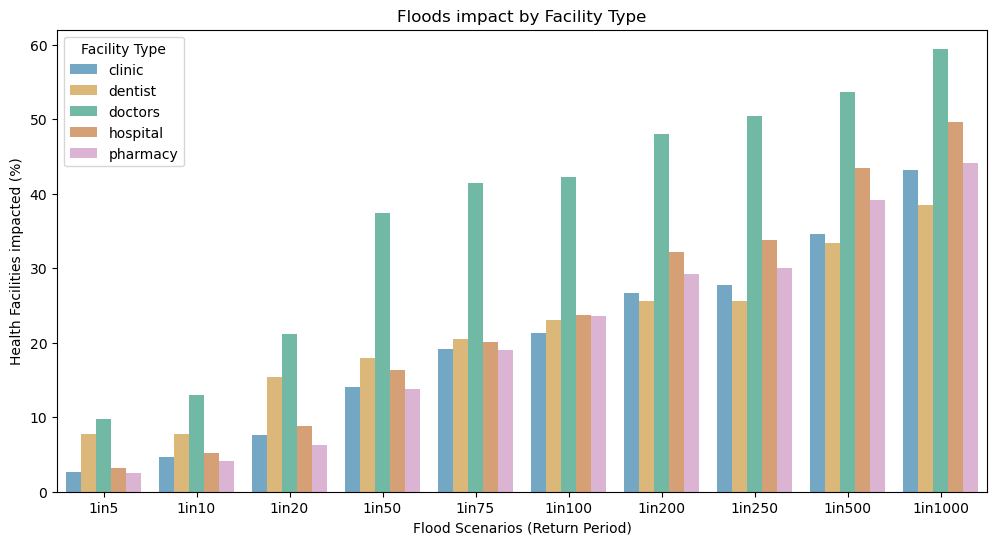

In [33]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Floods impact by Facility Type")
ax0.set_xticklabels(scen)
ax0.set_xlabel("Flood Scenarios (Return Period)")
ax0.set_ylabel("Health Facilities impacted (%)")
ax0.set_ylim(0,62)
ax0.legend(loc='upper left', fontsize = 10, title = "Facility type")
ax0 = sns.barplot(
    data=stats1_long, hue="Facility Type",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)

plt.savefig(join(out_path, iso, title + ".png"), dpi=300, bbox_inches='tight', facecolor='white')

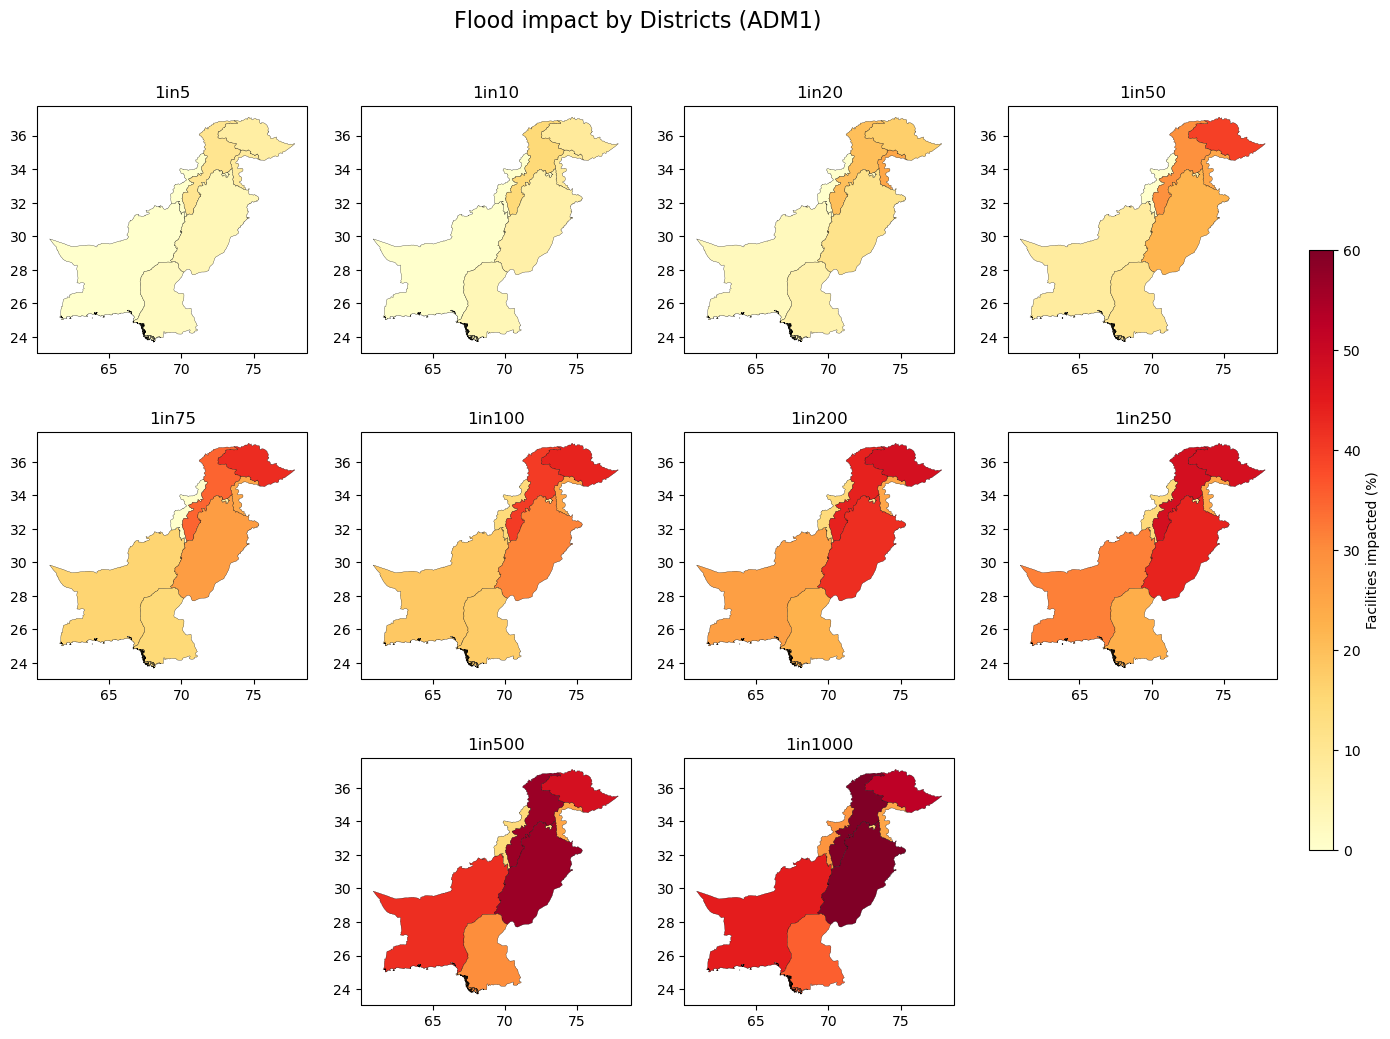

In [51]:
figsize = (16, 12)
fig = plt.figure(figsize=figsize)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(3, 4)

title = "Flood impact by Districts (ADM1)"
fig.suptitle(title, size=16, y=0.95)

# Define the colormap
cmap = plt.get_cmap('YlOrRd')
# Define the normalization from 0 to 45
norm = colors.Normalize(vmin=0, vmax=60)

for i, flood in enumerate(scen):
    if i < 4:
        ax = fig.add_subplot(gs[0, i], projection=projection)
    if ((i > 3) and (i < 8)):
        ax = fig.add_subplot(gs[1, i-4], projection=projection)
    if i > 7:
        ax = fig.add_subplot(gs[2, i-7], projection=projection)
    
    ax.set_title(flood)
    ax.get_xaxis().set_visible(True)
    ax.get_yaxis().set_visible(True)

    # Plot the data
    stats2.plot(
        ax=ax, column=flood, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        norm=norm
    )
    # ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [flood_dict_rio[key].bounds[0], flood_dict_rio[key].bounds[2],
    #                                                                           flood_dict_rio[key].bounds[1], flood_dict_rio[key].bounds[3]])
    
# Add a colorbar to the figure, adjusting its position via `fig.add_axes`
cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # Adjust the position and size of the colorbar here
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Facilities impacted (%)")

plt.show()


In [ ]:
#-- set environment variable CARTOPY_USER_BACKGROUNDS
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

FD = "1in500"

figsize = (14,12)
fig = plt.figure(figsize = figsize)
projection = ccrs.PlateCarree()
ax1 = fig.add_subplot(1, 2, 1, projection=projection)

fonttitle = {'fontname':'Open Sans','weight':'bold','size':18}
# fig.suptitle("Sectoral severity of needs", size = 16, weight = "bold", y = 0.93)
ax1.set_title("Flood Impact on Hospitals", weight = "bold", size = 14)

ax1.get_xaxis().set_visible(True) # plt.axis('off')
ax1.get_yaxis().set_visible(True)

# ax1 = gdf_adm3_severity.plot(
#     ax=ax, column='Severity', cmap='YlOrRd', legend=True,
#     alpha=1, linewidth=0.2, edgecolor='black', 
#     # classification_kwds = {'bins': [0,1,2,3,4]}, scheme='user_defined'
#     categorical = True,
#     legend_kwds = {
#         "loc": "upper right",
#         "bbox_to_anchor": (1.42, 1),
#         'title': "Severity index", 
#         'fontsize': 10,
#         'fmt': "{}",
#         'title_fontsize': 12
#     }
# )


ax1 = adm0.plot(ax=ax1, facecolor="none", edgecolor='red')

ax1 = dry_geodf_hf_hosp[FD].plot(ax=ax1, legend = True,
                         facecolor='green', edgecolor='green', marker = "o", markersize=60, #alpha=0.6,
                         categorical = True,
                         legend_kwds = {
                            "loc": "upper right",
                            "bbox_to_anchor": (1.42, 1),
                            'title': "Flood depth", 
                            'fontsize': 10,
                            'fmt': "{}",
                            'title_fontsize': 12
                        })

ax1 = flood_geodf_hf_hosp[FD].plot(ax=ax1, legend = True,
                         facecolor='red', edgecolor='black', marker = "o", markersize=100, #alpha=0.6,
                         categorical = True,
                         legend_kwds = {
                            "loc": "upper right",
                            "bbox_to_anchor": (1.42, 1),
                            'title': "Flood depth", 
                            'fontsize': 10,
                            'fmt': "{}",
                            'title_fontsize': 12
                        })

minx = adm0.geometry.bounds.minx[0]
maxx = adm0.geometry.bounds.maxx[0]
miny = adm0.geometry.bounds.miny[0]
maxy = adm0.geometry.bounds.maxy[0]

ax1.set_extent([minx-0.5, maxx+0.5, miny-0.5, maxy+0.5])

# ax1.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# Plot legends for GeoDataFrames
# legend1 = ax1.get_legend()

# Manually create new artists legends
legend1 = ax1.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='black', markersize=8, alpha=1),
                                    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markeredgecolor='white',markersize=6, alpha=1)],
                        labels=['Flooded hospitals', 'Safe hospitals'], loc="upper left")

# Combine legends
ax1.add_artist(legend1)
# ax1.add_artist(legend1plus)

# txt = "Severity"
# txt2 = "Fatalities as reported from the ACLED dataset (2010-2024)"
# plt.figtext(0.15, 0.07, txt, wrap=True, horizontalalignment='left', fontsize=10)
# plt.figtext(0.58, 0.07, txt2, wrap=True, horizontalalignment='left', fontsize=10)
# plt.savefig("Flood Impact on Health facilities - Malawi.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

## Access to roads

Consider the raw Fmax flood rasters, thus exploiting the original FATHOM dataset resolution.

Percentage of Health Facilities having direct access to an all-season road, by district (admin-2 level).​

Assumptions:

- All Health facilities considered are: Hospital, Health Post, Village Clinic, Health Centre, Dispensary and Outreach
- Floods impact all roads except primary and secondary bridges.
- Roads are disrupted if Flood Depth is > 30 cm.
- All-season road defined as primary and secondary or tertiary using the OpenStreetMap classification.
- Direct access defined as being within 100 meters of a road.​

Load OSM roads and define classification 
``` python
{
    'motorway': 'OSMLR level 1',
    'motorway_link': 'OSMLR level 1',
    'trunk': 'OSMLR level 1',
    'trunk_link': 'OSMLR level 1',
    'primary': 'OSMLR level 1',
    'primary_link': 'OSMLR level 1',
    'secondary': 'OSMLR level 2',
    'secondary_link': 'OSMLR level 2',
    'tertiary': 'OSMLR level 2',
    'tertiary_link': 'OSMLR level 2',
    'unclassified': 'OSMLR level 3',
    'unclassified_link': 'OSMLR level 3',
    'residential': 'OSMLR level 3',
    'residential_link': 'OSMLR level 3',
    'track': 'OSMLR level 4',
    'service': 'OSMLR level 4'
}
 ```

In [ ]:
# Only for the first time, need to download OSM .shp

# download_osm_shapefiles('asia', 'pakistan', Path(join(data_dir, iso)))

The road disruption analysis is executed with a standalone .py code to take advantage of multiprocessing

In [ ]:
! ./parallel.sh

Number of CPU: 256
CPU Usage: 2.2
Memory Total: GB 1081.808326656
Memory Used: GB 184.76824576
Memory Free: GB 46.736207872
VECTORIZATION started...


In [53]:
%%time

# Load the Road network

roads = dask_gpd.read_file(join(data_dir, iso, "pakistan-latest-free.shp", 'gis_osm_roads_free_1.shp'), npartitions = 8)
roads = roads.to_crs(epsg)

def get_num(x):
    try:
        return(int(x))
    except:
        return(5)
# roads.rename(columns = {"fclass":"OSMLR_num"}, inplace = True)
roads['OSMLR_num'] = roads['fclass'].apply(lambda x: get_num(str(x)[-1]))


CPU times: user 20.6 ms, sys: 24.3 ms, total: 44.9 ms
Wall time: 43.9 ms


In [55]:
roads_1in100 = dask_gpd.read_file(join(out_path, iso, "roads_impact_1in100.shp"), npartitions = 8)
roads_1in100 = roads_1in100.compute()

,osm_id,fclass,bridge,OSMLR_num,geometry
0,983169991,tertiary,T,5,"LINESTRING (73.20917 36.81111, 73.20913 36.81117)"
1,565685918,path,T,5,"LINESTRING (73.10700 36.82366, 73.10700 36.82373)"
2,565685917,path,F,5,"LINESTRING (73.10700 36.82373, 73.10700 36.82379)"
3,565685910,path,F,5,"LINESTRING (73.10346 36.82511, 73.10359 36.825..."
4,983169990,tertiary,F,5,"LINESTRING (73.20913 36.81117, 73.20908 36.811..."
...,...,...,...,...,...
298776,1240647325,service,F,5,"LINESTRING (69.76081 24.16912, 69.76090 24.169..."
298777,1241000299,service,F,5,"LINESTRING (69.83021 24.16911, 69.83019 24.16959)"
298778,1240647360,tertiary,F,5,"LINESTRING (69.85365 24.16956, 69.85177 24.169..."
298779,1240647338,tertiary,F,5,"LINESTRING (69.78602 24.16961, 69.78222 24.169..."


Baseline scenario

In [ ]:
%%time
import multiprocessing
from functools import partial

## Intersection using multiprocessing
def intersect_chunk(df_chunk, roads_geom):
    df_chunk.loc[:, "bool_2_100m_baseline"] = df_chunk.intersects(roads_geom)
    return df_chunk

num_cores = multiprocessing.cpu_count()
chunksize = int(len(data_health) / num_cores)  # Adjust chunk size if needed
pool = multiprocessing.Pool(num_cores)
results = pool.map(partial(intersect_chunk(data_health.iloc[i:i + chunksize], roads_geom=roads_2_100m) for i in range(0, len(data_health), chunksize)))
pool.close()
pool.join()

test = pd.concat(results)

In [ ]:
data_health = geodf_hf.copy().to_crs(epsg_utm) #[~(geodf_hf['Facility Type'] == "Outreach")]

## Calculate buffers
roads_100m = roads.copy().to_crs(epsg_utm)
roads_100m['geometry'] = roads_100m['geometry'].apply(lambda x: x.buffer(100))

roads_2km = roads.copy().to_crs(epsg_utm)
roads_2km['geometry'] = roads_2km['geometry'].apply(lambda x: x.buffer(2000))

## Intersect roads and buffer
# roads_1_100m = roads_100m.loc[roads_100m.OSMLR_num<=1].unary_union
roads_2_100m = roads_100m.loc[roads_100m.OSMLR_num<=2].unary_union
# roads_3 = roads.loc[roads.OSMLR_num<=3].unary_union
# roads_4 = roads.loc[roads.OSMLR_num<=4].unary_union

# geodf_hf.loc[:, "bool_1_100m"] = geodf_hf.intersects(roads_1_100m)
data_health.loc[:, "bool_2_100m_baseline"] = data_health.intersects(roads_2_100m)
# geodf_hf.loc[:, "bool_3"] = geodf_hf.intersects(roads_3)
# geodf_hf.loc[:, "bool_4"] = geodf_hf.intersects(roads_4)

# roads_1_2km = roads_2km.loc[roads_2km.OSMLR_num<=1].unary_union
roads_2_2km = roads_2km.loc[roads_2km.OSMLR_num<=2].unary_union
# roads_3 = roads.loc[roads.OSMLR_num<=3].unary_union
# roads_4 = roads.loc[roads.OSMLR_num<=4].unary_union

# geodf_hf.loc[:, "bool_1_2km"] = geodf_hf.intersects(roads_1_2km)
data_health.loc[:, "bool_2_2km_baseline"] = data_health.intersects(roads_2_2km)
# geodf_hf.loc[:, "bool_3"] = geodf_hf.intersects(roads_3)
# geodf_hf.loc[:, "bool_4"] = geodf_hf.intersects(roads_4)

data_health = data_health.to_crs(epsg)
adm1 = adm1.to_crs(epsg)
geodf_hf_road_base = gpd.sjoin(data_health, adm1[['geometry']], how='left').drop(columns = "index_right")

## Get percentages
# res_osmlr = facilities[['bool_1_100m','bool_2_100m','bool_1_2km','bool_2_2km','WB_ADM2_CO']].groupby('WB_ADM2_CO').sum()
res_osmlr = geodf_hf_road_base[['bool_2_100m_baseline','bool_2_2km_baseline','ADM1']].groupby('ADM1').sum()
res_count = geodf_hf_road_base[['ADM1','bool_2_100m_baseline']].groupby('ADM1').count().rename(columns={'bool_2_100m_baseline':'count'})
res_osmlr_pct_base = res_osmlr.apply(lambda x: x/res_count['count'])
res_osmlr_pct_base.reset_index(inplace = True)

In [ ]:
res_osmlr_pct_base.head(2)

Floods scenarios

In [ ]:
data_health = geodf_hf[['ADM1', "geometry"]].copy().to_crs(epsg_utm)      # [~(geodf_hf['Facility Type'] == "Outreach")]

for key in roads_impact.keys():

    ## Calculate buffers
    roads_100m = roads_impact[key].copy().to_crs(epsg_utm)
    roads_100m['geometry'] = roads_100m['geometry'].apply(lambda x: x.buffer(100))

    roads_2km = roads_impact[key].copy().to_crs(epsg_utm)
    roads_2km['geometry'] = roads_2km['geometry'].apply(lambda x: x.buffer(2000))

    ## Intersect roads and buffer
    # roads_1_100m = roads_100m.loc[roads_100m.OSMLR_num<=1].unary_union
    roads_2_100m = roads_100m.loc[roads_100m.OSMLR_num<=2].unary_union
    # roads_3 = roads.loc[roads.OSMLR_num<=3].unary_union
    # roads_4 = roads.loc[roads.OSMLR_num<=4].unary_union

    # geodf_hf.loc[:, "bool_1_100m"] = geodf_hf.intersects(roads_1_100m)
    data_health.loc[:, "bool_2_100m_" + key] = data_health.intersects(roads_2_100m)
    # geodf_hf.loc[:, "bool_3"] = geodf_hf.intersects(roads_3)
    # geodf_hf.loc[:, "bool_4"] = geodf_hf.intersects(roads_4)

    # roads_1_2km = roads_2km.loc[roads_2km.OSMLR_num<=1].unary_union
    roads_2_2km = roads_2km.loc[roads_2km.OSMLR_num<=2].unary_union
    # roads_3 = roads.loc[roads.OSMLR_num<=3].unary_union
    # roads_4 = roads.loc[roads.OSMLR_num<=4].unary_union

    # geodf_hf.loc[:, "bool_1_2km"] = geodf_hf.intersects(roads_1_2km)
    data_health.loc[:, "bool_2_2km_" + key] = data_health.intersects(roads_2_2km)
    # geodf_hf.loc[:, "bool_3"] = geodf_hf.intersects(roads_3)
    # geodf_hf.loc[:, "bool_4"] = geodf_hf.intersects(roads_4)

data_health = data_health.to_crs(epsg)
adm1 = adm1.to_crs(epsg)

geodf_hf_road = gpd.sjoin(data_health, adm1[['geometry']], how='left').drop(columns = "index_right")
## Get percentages
# res_osmlr = facilities[['bool_1_100m','bool_2_100m','bool_1_2km','bool_2_2km','WB_ADM2_CO']].groupby('WB_ADM2_CO').sum()
columns = [col for col in geodf_hf_road.columns if col.startswith("bool")]
res_osmlr = geodf_hf_road[columns+['ADM1']].groupby('ADM1').sum()
res_count = geodf_hf_road[["bool_2_100m_"+key,'ADM1']].groupby('ADM1').count().rename(columns={'bool_2_100m_'+key:'count'})
res_osmlr_pct = res_osmlr.apply(lambda x: x/res_count['count'])
res_osmlr_pct.reset_index(inplace = True)
res_osmlr_pct.head(2)

In [ ]:
geo_res_osmlr_pct_base = gpd.GeoDataFrame(res_osmlr_pct_base, geometry=adm1.geometry, crs=epsg)
geo_res_osmlr_pct = gpd.GeoDataFrame(res_osmlr_pct, geometry=adm1.geometry, crs=epsg)

In [ ]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 3)

fig.suptitle("Flood impact on Roads Accessibility - Direct Access", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

scen_toplot = ["baseline", '1in50', '1in100', '1in200', '1in500', '1in1000']
for i, flood in enumerate(scen_toplot):
    if i < 3:
        ax = fig.add_subplot(gs[0,i], projection=projection)
    else:
        ax = fig.add_subplot(gs[1,i-3], projection=projection)

    ax.set_title(flood)
    ax.get_xaxis().set_visible(True) # plt.axis('off')
    ax.get_yaxis().set_visible(True)

    cmap = "hot"
    if i == 0:
        geo_res_osmlr_pct_base.plot(
        ax=ax, column="bool_2_100m_"+flood, cmap=cmap, legend=False,
        scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
        classification_kwds = {'bins': [0.1,0.15,0.2,0.25,0.3,0.4,0.6,0.7]},
        legend_kwds = {
            'title': "Health facilities within \n 100m of an all-season road (%)",
            "loc": "upper right",
            "bbox_to_anchor": (2.7, 1), 
            'fontsize': 10,
            'fmt': "{}",
            'title_fontsize': 12
        }
    )
        
    else:
        if i == 2:
            geo_res_osmlr_pct.plot(
            ax=ax, column="bool_2_100m_"+ flood, cmap=cmap, legend=True,
            scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
            classification_kwds = {'bins': [0.1,0.15,0.2,0.25,0.3,0.4,0.6,0.7]},
            legend_kwds = {
                'title': "Health facilities within 100m \n of an all-season road (%)",
                "loc": "upper right",
                "bbox_to_anchor": (2.8, 1), 
                'fontsize': 10,
                'fmt': "{:.0%}",
                'title_fontsize': 12
            }
        )
        else:
            geo_res_osmlr_pct.plot(
            ax=ax, column='bool_2_100m_'+flood, cmap=cmap, legend=False,
            scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
            classification_kwds = {'bins': [0.1,0.15,0.2,0.25,0.3,0.4,0.6,0.7]},
            legend_kwds = {
                'title': "Health facilities within 100m \n of an all-season road (%)", 
                'fontsize': 10,
                'fmt': "{}",
                'title_fontsize': 12
            }
        )
    
    # ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

In [ ]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 3)

fig.suptitle("Flood impact on Roads Accessibility - Direct Access", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

scen_toplot = ["baseline", '1in50', '1in100', '1in200', '1in500', '1in1000']
for i, flood in enumerate(scen_toplot):
    if i < 3:
        ax = fig.add_subplot(gs[0,i], projection=projection)
    else:
        ax = fig.add_subplot(gs[1,i-3], projection=projection)

    ax.set_title(flood)
    ax.get_xaxis().set_visible(True) # plt.axis('off')
    ax.get_yaxis().set_visible(True)

    cmap = "hot"
    if i == 0:
        geo_res_osmlr_pct_base.plot(
        ax=ax, column="bool_2_2km_"+flood, cmap=cmap, legend=False,
        scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
        classification_kwds = {'bins': [0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.7,0.8]},
        legend_kwds = {
            'title': "Health facilities within \n 2km of an all-season road (%)",
            "loc": "upper right",
            "bbox_to_anchor": (2.7, 1), 
            'fontsize': 10,
            'fmt': "{}",
            'title_fontsize': 12
        }
    )
        
    else:
        if i == 2:
            geo_res_osmlr_pct.plot(
            ax=ax, column="bool_2_2km_"+ flood, cmap=cmap, legend=True,
            scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
            classification_kwds = {'bins': [0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.7,0.8]},
            legend_kwds = {
                'title': "Health facilities within 2km \n of an all-season road (%)",
                "loc": "upper right",
                "bbox_to_anchor": (2.8, 1), 
                'fontsize': 10,
                'fmt': "{:.0%}",
                'title_fontsize': 12
            }
        )
        else:
            geo_res_osmlr_pct.plot(
            ax=ax, column='bool_2_2km_'+flood, cmap=cmap, legend=False,
            scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
            classification_kwds = {'bins': [0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.7,0.8]},
            legend_kwds = {
                'title': "Health facilities within 2km \n of an all-season road (%)", 
                'fontsize': 10,
                'fmt': "{}",
                'title_fontsize': 12
            }
        )
    
    # ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')